# Simulation Analysis


### 1. Import Packages
Here we will be using the reading and writing tools that come with the ParFlow tools package.  

In [1]:
from set_demo_defaults import *
import xarray as xr
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt

import parflow as pf
from parflow.tools.fs import get_absolute_path
from parflow.tools.io import write_pfb, read_pfb
from parflow import Run
import parflow.tools.hydrology as hydro

#setting the directory name that we will read our outputs from
sim_type = 'cap' #cap: capillarity, no-cap: no capillarity

# Name your ParFLow run -- note that all of your output files will have this prefix
if sim_type == 'cap':
    run_name = 'MA_via_conus2'
else:
    run_name = 'no_cap_MA_via_conus2'


#run_dir = get_absolute_path(f'outputs/{run_name}')

#run_dir = get_absolute_path(f"/scratch/network/ms6985//outputs/{run_name}')

# set the directory paths where you want to write your subset files
grid       = "conus2"
start      = "2018-01-01"
end        = "2023-01-01"
home       = "/scratch/network/ms6985" #make scratch home again
base_dir   = os.path.join(home, "subsettools_tutorial")
output_dir = os.path.join(base_dir, "outputs")
run_dir    = os.path.join(output_dir, f"{run_name}_{grid}_{end[:4]}WY")

print(run_dir)

/scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY


####  2. Read in the domain properties
First we will load the run from the pfidb file and get the properties using the [data_accessor](https://parflow.readthedocs.io/en/latest/tutorials/data_accessor.html?highlight=data_accessor) and by reading out the keys we need from the model object. 


In [2]:
run = Run.from_definition(f'{run_dir}/{run_name}.pfidb')
data = run.data_accessor
nt = len(data.times)
nx = data.shape[2]
ny = data.shape[1]
nz = data.shape[0]
dx = data.dx
dy = data.dy
dz = data.dz

print(nt,nx,ny,nz,dx,dy,dz)

porosity = data.computed_porosity 
specific_storage = data.specific_storage 
mannings = run.Mannings.Geom.domain.Value
#mannings = mannings*np.ones((ny, nx))
#print(mannings)

## remove input filenames for TopoSlopes to force the data accessor to read the output slopes
## this fixes a windows issue
run.TopoSlopesX.FileName = 'slope_x.pfb'
run.TopoSlopesY.FileName = 'slope_y.pfb'

slopex = data.slope_x 
slopey = data.slope_y 
mask = data.mask

# formatting the mask so that values outside the domain are NA and inside the domain are 1
nanmask=mask.copy()
nanmask[nanmask == 0] = 'NaN'
nanmask[nanmask > 0] = 1

Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
  - nt
  - sw_ini
  - hkdepth
  - wtfact
  - trsmx0
  - smpmax
  - pondmx


/home/SHARED/virtual-environments/parflow-shared/conda/lib/python3.11/site-packages/parflow/tools/io.py:1494: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_name, delim_whitespace=True, skiprows=2, header=None)


43801 38 45 10 1000.0 1000.0 [2.0e+02 1.0e+02 5.0e+01 2.5e+01 1.0e+01 5.0e+00 1.0e+00 6.0e-01 3.0e-01
 1.0e-01]


In [3]:
from parflow.tools.io import read_pfb
mannings = read_pfb(f'{run_dir}/mannings.pfb')
print(mannings)
print(np.shape(mannings))

[[[2.77777778e-05 2.77777778e-05 2.77777778e-05 ... 1.52777778e-05
   2.50000000e-05 2.77777778e-05]
  [2.77777778e-05 2.77777778e-05 2.77777778e-05 ... 2.77777778e-05
   2.77777778e-05 1.52777778e-05]
  [2.77777778e-05 2.77777778e-05 2.77777778e-05 ... 2.77777778e-05
   2.77777778e-05 2.77777778e-05]
  ...
  [2.77777778e-05 9.72222222e-06 2.77777778e-05 ... 2.77777778e-05
   2.77777778e-05 2.77777778e-05]
  [2.77777778e-05 2.77777778e-05 2.77777778e-05 ... 2.77777778e-05
   2.77777778e-05 2.77777778e-05]
  [2.77777778e-05 2.77777778e-05 2.77777778e-05 ... 2.77777778e-05
   2.77777778e-05 2.77777778e-05]]]
(1, 45, 38)


#### 4. Read the simulation output files


In [4]:
#list all pressure files from outputs
lw_press_files = glob(f'{run_dir}/*out.press*.pfb')
#print(lw_press_files)
#read in all pressure files into a 3D NParray
pressure_arrays = pf.read_pfb_sequence(lw_press_files) * nanmask

#list all saturation files from outputs
lw_satur_files = glob(f'{run_dir}/*out.satur*.pfb')
#read in all pressure files into a 3D NParray
saturation_arrays = pf.read_pfb_sequence(lw_satur_files) * nanmask

import pandas as pd

#list all ET files from outputs
lw_clm_output_files = glob(f'{run_dir}/*out.clm_output*.pfb')
CLM_data = pf.read_pfb_sequence(lw_clm_output_files) #* nanmask
#print out all CLM variables avilable
## create data frame for CLM output ET vars 
clm_output = pd.DataFrame({'SWE[mm]':CLM_data[:,10,0,0],'T_Grnd[K]':CLM_data[:,11,0,0],'T [mm/s]':CLM_data[:,8,0,0],'Ebs [mm/s]':CLM_data[:,6,0,0],'Qflux infil [mm/s]':CLM_data[:,9,0,0],'Qflux irrig [mm/s]':CLM_data[:,12,0,0],'qflx_evap_grnd [mm/s]':CLM_data[:,5,0,0] })
## the variables we use here are chosen to represent the fluxes passed to ParFlow, detailed below
#clm_output_full = pd.DataFrame({'T [mm/s]':CLM_data[:,8,0,:],'Ebs [mm/s]':CLM_data[:,6,0,:],'Qflux infil [mm/s]':CLM_data[:,9,0,:],'Qflux irrig [mm/s]':CLM_data[:,12,0,:],'qflx_evap_grnd [mm/s]':CLM_data[:,5,0,:] })

clm_output_T_mmps   = CLM_data[:,8,:,:]
clm_output_Ebs_mmps = CLM_data[:,6,:,:]
clm_output_T_Grnd_K = CLM_data[:,11,:,:]
clm_output_SWE_mm   = CLM_data[:,10,:,:]

#### 5. Calculate water balance
We will be using the hydrology tools to calculate the water balance. You can find more information on the tools [here](https://parflow.readthedocs.io/en/latest/tutorials/hydrology.html).

In [5]:
# Set up x and z to match the shape of the ParFlow grid
x = np.arange(0.0,(nx+1)*dx,dx)
y = np.arange(0.0,(ny+1)*dy,dy)
z = np.zeros(nz+1)
z[1:] = np.cumsum(dz)

subsurface_storage = np.zeros(nt)
subsurface_storage_arr= np.zeros((nt,nz, ny, nx))
surface_storage = np.zeros(nt)
wtd = np.zeros((nt, ny, nx))
et = np.zeros(nt)
overland_flow = np.zeros((nt, ny, nx))
data.time = 0

for i, (pressure, saturation) in enumerate(zip(pressure_arrays, saturation_arrays)):
    subsurface_storage[i, ...] = np.sum(hydro.calculate_subsurface_storage(porosity, pressure, saturation, specific_storage, dx, dy, dz, mask = nanmask),axis=(0, 1, 2))
    subsurface_storage_arr[i, ...] = hydro.calculate_subsurface_storage(porosity, pressure, saturation, specific_storage, dx, dy, dz, mask = nanmask)
    # total surface storage for this time step is the summation of substorage surface across all x/y slices
    surface_storage[i, ...] = np.sum( hydro.calculate_surface_storage(pressure, dx, dy, mask = nanmask),axis=(0, 1))
    wtd[i, ...] = hydro.calculate_water_table_depth(pressure, saturation, dz)
    
    data.time = i
    if i != 0:
        if data.et is not None:
            # total ET for this time step is the summation of ET values across all x/y/z slices
            et[i, ...] = np.sum(hydro.calculate_evapotranspiration(data.et, dx, dy, dz, mask = nanmask),axis=(0, 1, 2))

 
    overland_flow[i, ...] = hydro.calculate_overland_flow_grid(pressure, slopex, slopey, mannings, dx, dy, mask = nanmask)

In [6]:
print(np.shape(subsurface_storage_arr))

Delta_x = 1000 #1 km grid size in x direction
Delta_y = 1000 #1 km grid size in y direction
Delta_z = [200, 100, 50, 25, 10, 5, 1, 0.6, 0.3, 0.1] #cell thickness in vertical direction from bottom to top [m]

soil_moisture_1m = np.sum(subsurface_storage_arr[:,-3:-1,:,:],axis=1)/(Delta_x*Delta_y*1) #[m3/m3]
soil_moisture_2m = np.sum(subsurface_storage_arr[:,-4:-1,:,:],axis=1)/(Delta_x*Delta_y*2) #[m3/m3]
soil_moisture_point10cmavg = subsurface_storage_arr[:,-1,:,:]/(Delta_x*Delta_y*Delta_z[-1]) #[m3/m3]  #10cm thick cell
soil_moisture_point25cmavg = subsurface_storage_arr[:,-2,:,:]/(Delta_x*Delta_y*Delta_z[-2]) #[m3/m3]  #25cm thick cell

print(np.shape(soil_moisture_1m))
print(np.shape(soil_moisture_2m))

(43801, 10, 45, 38)
(43801, 45, 38)
(43801, 45, 38)


### Plot Static maps of the simulation outputs

(43801, 45, 38)
(43801, 10, 45, 38)


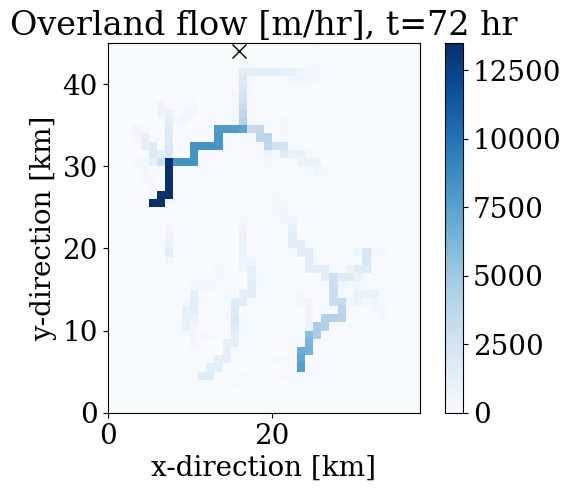

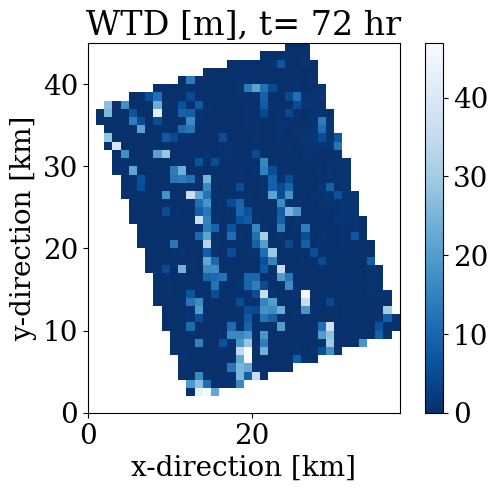

('eflx_lh_tot', 'eflx_lwrad_out', 'eflx_sh_tot', 'eflx_soil_grnd', 'qflx_evap_tot', 'qflx_evap_grnd', 'qflx_evap_soi', 'qflx_evap_veg', 'qflx_tran_veg', 'qflx_infl', 'swe_out', 't_grnd', 'qflx_qirr', 't_soil')


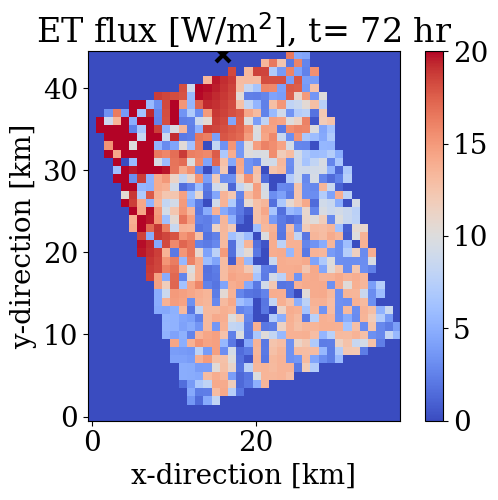

In [7]:
#CLM data array format 
# reading the CLM file PFCLM_SC.out.clm_output.<file number>.C.pfb
# variables are by layer:
# 0 eflx_lh_tot:  total latent heat flux (Wm-2)  
# 1 eflx_lwrad_out: total upward LW radiation (Wm-2)  
# 2 eflx_sh_tot: total sensible heat flux (Wm-2)  
# 3 eflx_soil_grnd: ground heat flux (Wm-2)    
# 4 qflx_evap_tot: net veg. evaporation and transpiration and soil evaporation (mms-1)  
# 5 qflx_evap_grnd: ground evaporation (mms-1)   
# 6 qflx_evap_soi: soil evaporation (mms-1)   
# 7 qflx_evap_veg: vegetation evaporation (canopy) and transpiration (mms-1)   
# 8 qflx_tran_veg: transpiration (mms-1)  
# 9 qflx_infl: infiltration flux (mms-1)   
# 10 swe_out: SWE (mm)   
# 11 t_grnd: ground temperature (K)  
# 12 irrigation flux
# 13 - 24 Soil temperature by layer (K)

print(np.shape(overland_flow))
print(np.shape(pressure_arrays))

icount = 72


fig, ax = plt.subplots(1)
ax.set_title("Overland flow [m/hr], t={} hr".format(icount))
plt.plot(x[16]/1e3,y[44]/1e3,'x',markersize=10,color='k',markeredgewidth=1)
#plt.imshow(overland_flow[icount,:,:], cmap="Blues", origin='lower')
im = ax.pcolormesh(x/1e3, y/1e3, overland_flow[icount,:,:], cmap="Blues") 
plt.colorbar(im, ax=ax)
plt.xlabel('x-direction [km]')
plt.ylabel('y-direction [km]')
ax.set_aspect('equal')
plt.savefig(f'MA_time{icount}hr_sim_type{sim_type}_overland.pdf',bbox_inches='tight', dpi = 600)
plt.show()

# To equalize our aspect ratio

fig, ax = plt.subplots(1)
ax.set_title("WTD [m], t= {} hr".format(icount))
#plt.imshow(wtd[icount,:,:], cmap="Blues_r", origin='lower')
im = ax.pcolormesh(x/1e3, y/1e3, wtd[icount,:,:], cmap="Blues_r") 
plt.colorbar(im, ax=ax)
plt.xlabel('x-direction [km]')
plt.ylabel('y-direction [km]')
ax.set_aspect('equal')
plt.savefig(f'MA_time{icount}hr_sim_type{sim_type}_WTD.pdf',bbox_inches='tight', dpi = 600)
plt.show()

#print out all CLM variables avilable
print(data.clm_output_variables)
# set time
fig, ax = plt.subplots(1)
data.time = icount
# fileter out inactive cellsfig, ax = plt.subplots(1)
ax.set_title("ET flux [W/m$^2$], t= {} hr".format(icount))
LH_plot = np.where(data.clm_output(field='eflx_lh_tot') > -99, data.clm_output(field='eflx_lh_tot'), 0.)
#im = ax.pcolormesh(x/1e3, y/1e3, LH_plot, cmap="coolwarm") 
im = plt.imshow(LH_plot, cmap="coolwarm", origin='lower',vmin=0, vmax=20)
plt.plot(x[16]/1e3,y[44]/1e3,'x',markersize=10,color='k',markeredgewidth=3)
plt.colorbar()
#plt.colorbar(im, ax=ax)
plt.xlabel('x-direction [km]')
plt.ylabel('y-direction [km]')
ax.set_aspect('equal')
plt.savefig(f'MA_time{icount}hr_sim_type{sim_type}_ETfluxes.pdf',bbox_inches='tight', dpi = 600)
plt.show()

# plot average values throughout year

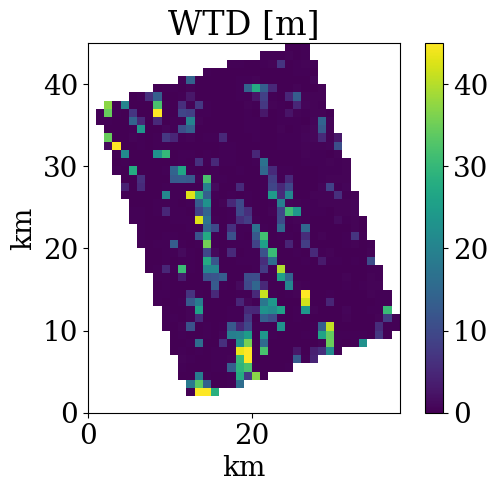

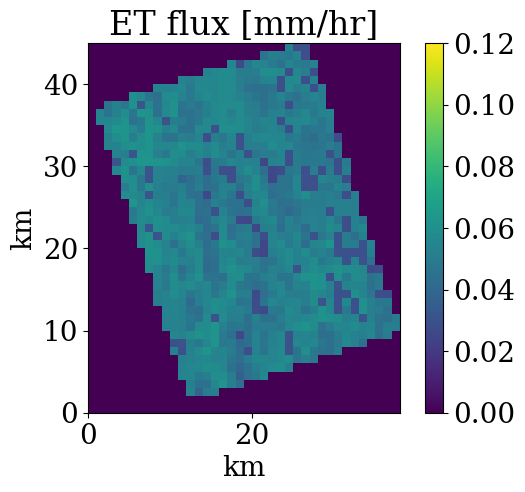

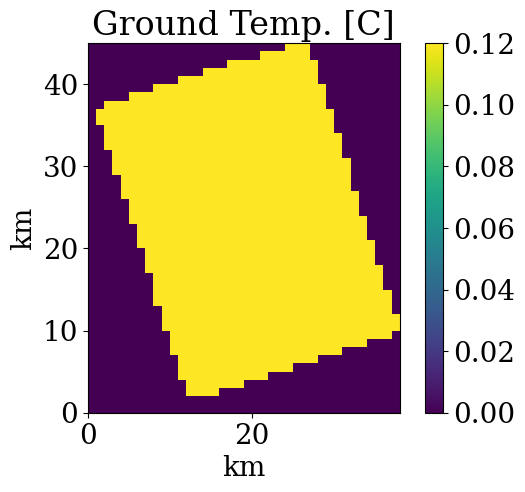

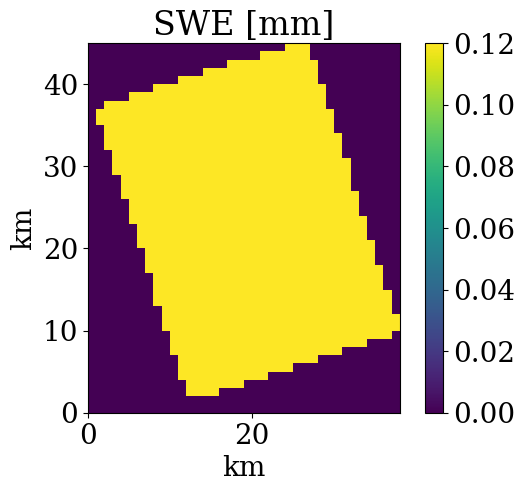

In [8]:
#Plot average ET in a year and average WTD
fig, ax = plt.subplots(1)
ax.set_title("WTD [m]".format(icount))
#plt.imshow(wtd[icount,:,:], cmap="Blues_r", origin='lower')
im = ax.pcolormesh(x/1e3, y/1e3, np.mean(wtd,axis=0), cmap="viridis", shading='auto', vmin=0, vmax=45) 
plt.colorbar(im, ax=ax)
plt.xlabel('km')
plt.ylabel('km')
ax.set_aspect('equal')
plt.savefig(f'MA_time_avg_hr_sim_type{sim_type}_WTD.pdf',bbox_inches='tight', dpi = 600)
plt.savefig(f'MA_time_avg_hr_sim_type{sim_type}_WTD.png',bbox_inches='tight', dpi = 600)
plt.show()

# --- plotting ---
fig, ax = plt.subplots(1)
ax.set_title("ET flux [mm/hr]")
im = ax.pcolormesh(x/1e3, y/1e3,
     np.mean((clm_output_T_mmps + clm_output_Ebs_mmps) * 60 * 60, axis=0),
     cmap="viridis", shading='auto', vmin=0, vmax=0.12)
plt.colorbar(im, ax=ax)
plt.xlabel('km')
plt.ylabel('km')
ax.set_aspect('equal')
plt.savefig(f"MA_time_avg_hr_sim_type{sim_type}_ETfluxes.pdf",
            bbox_inches='tight', dpi=600)
plt.savefig(f"MA_time_avg_hr_sim_type{sim_type}_ETfluxes.png",
            bbox_inches='tight', dpi=600)
plt.show()


# --- plotting ---
fig, ax = plt.subplots(1)
ax.set_title("Ground Temp. [C]")
im = ax.pcolormesh(x/1e3, y/1e3,
     np.mean(clm_output_T_Grnd_K-273.16, axis=0),
     cmap="viridis", shading='auto', vmin=0, vmax=0.12)
plt.colorbar(im, ax=ax)
plt.xlabel('km')
plt.ylabel('km')
ax.set_aspect('equal')
plt.savefig(f"MA_time_avg_hr_sim_type{sim_type}_Grnd_T.pdf",
            bbox_inches='tight', dpi=600)
plt.savefig(f"MA_time_avg_hr_sim_type{sim_type}_Grnd_T.png",
            bbox_inches='tight', dpi=600)
plt.show()


# --- plotting ---
fig, ax = plt.subplots(1)
ax.set_title("SWE [mm]")
im = ax.pcolormesh(x/1e3, y/1e3,
     np.mean(clm_output_SWE_mm, axis=0),
     cmap="viridis", shading='auto', vmin=0, vmax=0.12)
plt.colorbar(im, ax=ax)
plt.xlabel('km')
plt.ylabel('km')
ax.set_aspect('equal')
plt.savefig(f"MA_time_avg_hr_sim_type{sim_type}_SWE.pdf",
            bbox_inches='tight', dpi=600)
plt.savefig(f"MA_time_avg_hr_sim_type{sim_type}_SWE.png",
            bbox_inches='tight', dpi=600)
plt.show()

### plotting components of water balance

In [10]:
!pwd

/home/ms6985/Andreas


In [11]:
np.shape(data.clm_output(field='eflx_lh_tot'))

(45, 38)

In [12]:
run_dir

'/scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY'

In [13]:
np.shape(CLM_data)

(43800, 17, 45, 38)

In [14]:
np.shape(saturation_arrays)

(43801, 10, 45, 38)

In [15]:
np.shape(porosity)

(10, 45, 38)

In [16]:
clm_output['SWE[mm]']

0       -9999.0
1       -9999.0
2       -9999.0
3       -9999.0
4       -9999.0
          ...  
43795   -9999.0
43796   -9999.0
43797   -9999.0
43798   -9999.0
43799   -9999.0
Name: SWE[mm], Length: 43800, dtype: float64

In [17]:
clm_output['TGrnd[K]']

KeyError: 'TGrnd[K]'

soil_moisture_1m shape: (43801, 45, 38)
ET shape: (43800, 45, 38)
Ground Temp shape: (43800, 45, 38)
SWE shape: (43800, 45, 38)
Ground temp limits: -10272.16 24.063283232169553
SWE limits: -9999.0 50.63479843022462
Creating video: /scratch/network/ms6985/subsettools_tutorial/outputs/MA_via_conus2_conus2_2023WY/../MA_time_video_sim_typecap_WTD_ET_GrndTemp_SWE.gif
Frame 0/43801 complete...
Frame 600/43801 complete...
Frame 1200/43801 complete...
Frame 1800/43801 complete...
Frame 2400/43801 complete...
Frame 3000/43801 complete...
Frame 3600/43801 complete...
Frame 4200/43801 complete...
Frame 4800/43801 complete...
Frame 5400/43801 complete...
Frame 6000/43801 complete...
Frame 6600/43801 complete...
Frame 7200/43801 complete...
Frame 7800/43801 complete...
Frame 8400/43801 complete...
Frame 9000/43801 complete...
Frame 9600/43801 complete...
Frame 10200/43801 complete...
Frame 10800/43801 complete...
Frame 11400/43801 complete...
Frame 12000/43801 complete...
Frame 12600/43801 complete

IndexError: index 43800 is out of bounds for axis 0 with size 43800

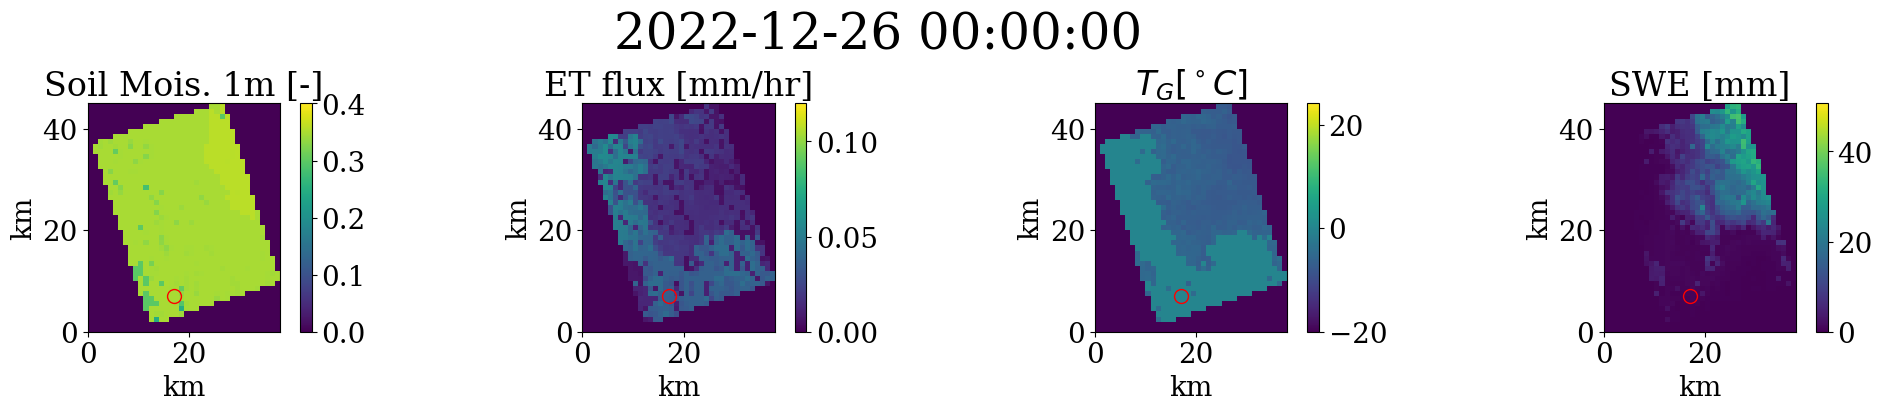

In [18]:
# ============================================================
# Make a 4-panel video of:
#   1) WTD [m]
#   2) ET flux [mm/hr]
#   3) Ground Temp [C]
#   4) SWE [mm]
# with time shown at the top
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime, timedelta

# ------------------------------------------------------------
# Time array example
# Adjust the start date if needed
# ------------------------------------------------------------
d = datetime(2018, 1, 1, 0, 0)
nt = wtd.shape[0]
t_time_datetime = [d + timedelta(hours=i) for i in range(nt)]

# ------------------------------------------------------------
# Derived variables
# ------------------------------------------------------------
et_mmhr = (clm_output_T_mmps + clm_output_Ebs_mmps) * 3600.0
grnd_temp_C = clm_output_T_Grnd_K - 273.16
swe_mm = clm_output_SWE_mm

# ------------------------------------------------------------
# Optional masking if you have invalid values
# Uncomment and edit if needed
# ------------------------------------------------------------
# wtd_plot = np.where(wtd > -999, wtd, np.nan)
# et_plot = np.where(et_mmhr > -999, et_mmhr, np.nan)
# grnd_plot = np.where(grnd_temp_C > -999, grnd_temp_C, np.nan)
# swe_plot = np.where(swe_mm > -999, swe_mm, np.nan)

# If no masking needed:
soil_moisture_1m_plot = soil_moisture_1m
et_plot = et_mmhr
grnd_plot = grnd_temp_C
swe_plot = swe_mm

# ------------------------------------------------------------
# Color limits
# You can change these manually if you want
# ------------------------------------------------------------
soil_moisture_1m_vmin, soil_moisture_1m_vmax = 0, 0.4
et_vmin, et_vmax = 0, 0.12

grnd_vmin = np.nanpercentile(grnd_plot, 2)
grnd_vmax = np.nanpercentile(grnd_plot, 98)

swe_vmin = np.nanpercentile(swe_plot, 2)
swe_vmax = np.nanpercentile(swe_plot, 98)

print("soil_moisture_1m shape:", soil_moisture_1m_plot.shape)
print("ET shape:", et_plot.shape)
print("Ground Temp shape:", grnd_plot.shape)
print("SWE shape:", swe_plot.shape)

print("Ground temp limits:", grnd_vmin, grnd_vmax)
print("SWE limits:", swe_vmin, swe_vmax)

# ------------------------------------------------------------
# Video settings
# ------------------------------------------------------------
fps = 10
step = 120
writer = animation.PillowWriter(fps=fps)
video_name = f"{run_dir}/../MA_time_video_sim_type{sim_type}_WTD_ET_GrndTemp_SWE.gif"

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1,4, figsize=(20, 4), constrained_layout=True)
ax1, ax2, ax3, ax4 = axes.ravel()

# Initial frame
icount = 0

im1 = ax1.pcolormesh(
    x / 1e3, y / 1e3, soil_moisture_1m_plot[icount, :, :],
    cmap="viridis", shading="auto", vmin=soil_moisture_1m_vmin, vmax=soil_moisture_1m_vmax
)
ax1.set_title("Soil Mois. 1m [-]")
ax1.set_xlabel("km")
ax1.set_ylabel("km")
ax1.set_aspect("equal")

im2 = ax2.pcolormesh(
    x / 1e3, y / 1e3, et_plot[icount, :, :],
    cmap="viridis", shading="auto", vmin=0, vmax=et_vmax
)
ax2.set_title("ET flux [mm/hr]")
ax2.set_xlabel("km")
ax2.set_ylabel("km")
ax2.set_aspect("equal")

im3 = ax3.pcolormesh(
    x / 1e3, y / 1e3, grnd_plot[icount, :, :],
    cmap="viridis", shading="auto", vmin=-20, vmax=grnd_vmax
)
ax3.set_title("$T_G[^\circ C]$")
ax3.set_xlabel("km")
ax3.set_ylabel("km")
ax3.set_aspect("equal")

im4 = ax4.pcolormesh(
    x / 1e3, y / 1e3, swe_plot[icount, :, :],
    cmap="viridis", shading="auto", vmin=0, vmax=swe_vmax
)
ax1.plot(x[17] / 1e3,y[7] / 1e3,marker='o',linestyle='None',markerfacecolor='none',markeredgecolor='red',markersize=10)
ax2.plot(x[17] / 1e3,y[7] / 1e3,marker='o',linestyle='None',markerfacecolor='none',markeredgecolor='red',markersize=10)
ax3.plot(x[17] / 1e3,y[7] / 1e3,marker='o',linestyle='None',markerfacecolor='none',markeredgecolor='red',markersize=10)
ax4.plot(x[17] / 1e3,y[7] / 1e3,marker='o',linestyle='None',markerfacecolor='none',markeredgecolor='red',markersize=10)

ax4.set_title("SWE [mm]")
ax4.set_xlabel("km")
ax4.set_ylabel("km")
ax4.set_aspect("equal")

# Colorbars
cbar1 = fig.colorbar(im1, ax=ax1)
cbar2 = fig.colorbar(im2, ax=ax2)
cbar3 = fig.colorbar(im3, ax=ax3)
cbar4 = fig.colorbar(im4, ax=ax4)

#cbar1.set_label("[-]")
#cbar2.set_label("mm/hr")
#cbar3.set_label("C")
#cbar4.set_label("mm")

# Global title
suptitle = fig.suptitle(f"{t_time_datetime[icount]}", fontsize=36)

print(f"Creating video: {video_name}")

# ------------------------------------------------------------
# Write frames
# ------------------------------------------------------------
with writer.saving(fig, video_name, dpi=300):
    for icount in range(0, nt, step):

        im1.set_array(soil_moisture_1m_plot[icount, :, :].ravel())
        im2.set_array(et_plot[icount, :, :].ravel())
        im3.set_array(grnd_plot[icount, :, :].ravel())
        im4.set_array(swe_plot[icount, :, :].ravel())

        suptitle.set_text(f"{t_time_datetime[icount]}")

        writer.grab_frame()

        if icount % 50 == 0:
            print(f"Frame {icount}/{nt} complete...")

plt.close(fig)
print(f"Finished writing video: {video_name}")


In [ ]:
#np.count_nonzero(~np.isnan(nanmask))
print(np.count_nonzero(~np.isnan(nanmask[-1,:,:])))
np.shape(np.kron(nanmask[-1,:,:],np.ones(((10,1,1)))))
np.kron(nanmask[-1,:,:],np.ones(((10,1,1))))

In [ ]:
from datetime import datetime, timedelta
d = datetime(2018, 1, 1, 0, 0)

#print(d + timedelta(hours = time_array_plot[0,2]))
time_array_one_row = np.linspace(0,43800,43801)#time_array_plot[0,:]

time_array_datetime = ([d + timedelta(hours = i) for i in time_array_one_row])

#time_array_datetime = np.tile(t_time_datetime, (20,1))

#plotting components of water balance
fig, axs = plt.subplots(4, sharex=True, figsize=(8,10) , dpi=100)
#fig.suptitle('Little Washita Water Balance')
axs[0].plot(time_array_datetime,np.nanmean(soil_moisture_1m*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row),1,1)))), axis=(1,2)), linewidth=2, color = red,label='Avg')
axs[0].plot(time_array_datetime,soil_moisture_1m[:,17,7], 'k--', linewidth=2,alpha=1,label='MA423')
axs[0].set_ylabel("SM [m$^3$/m$^3$]")
axs[0].legend(loc='lower left')
axs[1].plot(time_array_datetime[1:],np.nanmean(et_plot*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[1].plot(time_array_datetime[1:],et_plot[:,17,7], 'k--', linewidth=2,alpha=0.5)
axs[1].set_ylabel("ET [mm/hr]")
axs[2].plot(time_array_datetime[1:],np.nanmean(grnd_plot*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[2].plot(time_array_datetime[1:],grnd_plot[:,17,7], 'k--', linewidth=2,alpha=1)
axs[2].set_ylabel("$T_G$ [$^\circ$C]")
axs[3].plot(time_array_datetime[1:],np.nanmean(swe_plot*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[3].plot(time_array_datetime[1:],swe_plot[:,17,7], 'k--', linewidth=2,alpha=1)
axs[3].set_ylabel("SWE [mm]")
plt.xlabel('Calendar date')
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xticks(rotation = 30)
plt.savefig(f'{run_dir}/../MA_time_sim_type{sim_type}_all.pdf',bbox_inches='tight', dpi = 600)
plt.savefig(f'{run_dir}/../MA_time_sim_type{sim_type}_all.png',bbox_inches='tight', dpi = 600)
np.savez(f'{run_dir}/../MA_time{icount}hr_sim_type{sim_type}_storage',time_array_datetime,et_plot,soil_moisture_1m,grnd_plot,swe_plot)  

In [ ]:
np.shape(soil_moisture_1m)[1]*np.shape(soil_moisture_1m)[2]

In [ ]:
#Only for the year 2022

from datetime import datetime, timedelta
d = datetime(2018, 1, 1, 0, 0)

#print(d + timedelta(hours = time_array_plot[0,2]))
time_array_one_row = np.linspace(8760*4,8760*5,8761)#time_array_plot[0,:]

time_array_datetime = ([d + timedelta(hours = i) for i in time_array_one_row])

#time_array_datetime = np.tile(t_time_datetime, (20,1))

#plotting components of water balance
fig, axs = plt.subplots(4, sharex=True, figsize=(8,10) , dpi=100)
#fig.suptitle('Little Washita Water Balance')
axs[0].plot(time_array_datetime,np.nanmean(soil_moisture_1m[8760*4-1:8760*5]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row),1,1)))), axis=(1,2)), linewidth=2, color = red,label='Avg')
axs[0].plot(time_array_datetime,soil_moisture_1m[8760*4-1:8760*5,17,7], 'k--', linewidth=2,alpha=1,label='MA423')
axs[0].legend(loc='lower left')
axs[0].set_ylabel("SM [m$^3$/m$^3$]")
axs[1].plot(time_array_datetime[1:],np.nanmean(et_plot[8760*4-1:8760*5-1]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[1].plot(time_array_datetime[1:],et_plot[8760*4-1:8760*5-1,17,7], 'k--', linewidth=2,alpha=0.5)
axs[1].set_ylabel("ET [mm/hr]")
axs[2].plot(time_array_datetime[1:],np.nanmean(grnd_plot[8760*4-1:8760*5-1]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[2].plot(time_array_datetime[1:],grnd_plot[8760*4-1:8760*5-1,17,7], 'k--', linewidth=2,alpha=1)
axs[2].set_ylabel("$T_G$ [$^\circ$C]")
axs[3].plot(time_array_datetime[1:],np.nanmean(swe_plot[8760*4-1:8760*5-1]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[3].plot(time_array_datetime[1:],swe_plot[8760*4-1:8760*5-1,17,7], 'k--', linewidth=2,alpha=1)
axs[3].set_ylabel("SWE [mm]")
plt.xlabel('Calendar date')
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xticks(rotation = 30)
plt.savefig(f'{run_dir}/../MA_time_sim_type{sim_type}_all_2022.pdf',bbox_inches='tight', dpi = 600)
plt.savefig(f'{run_dir}/../MA_time_sim_type{sim_type}_all_2022.png',bbox_inches='tight', dpi = 600)
np.savez(f'{run_dir}/../MA_time{icount}hr_sim_type{sim_type}_storage_2022',time_array_datetime,et_plot,soil_moisture_1m,grnd_plot,swe_plot)  

In [ ]:
#Only for specific time in 2022: 24th April to 3rd October

from datetime import datetime, timedelta
d = datetime(2018, 1, 1, 0, 0)

#print(d + timedelta(hours = time_array_plot[0,2]))
time_array_one_row = np.linspace(8760*4+2735,8760*4+5135,2401)#time_array_plot[0,:]

time_array_datetime = ([d + timedelta(hours = i) for i in time_array_one_row])

#time_array_datetime = np.tile(t_time_datetime, (20,1))

#plotting components of water balance
fig, axs = plt.subplots(4, sharex=True, figsize=(8,10) , dpi=100)
#fig.suptitle('Little Washita Water Balance')
axs[0].plot(time_array_datetime,np.nanmean(soil_moisture_1m[8760*4+2735-1:8760*4+5135]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row),1,1)))), axis=(1,2)), linewidth=2, color = red,label='Avg')
axs[0].plot(time_array_datetime,soil_moisture_1m[8760*4+2735-1:8760*4+5135,17,7], 'k--', linewidth=2,alpha=1,label='MA423')
axs[0].legend(loc='lower left')
axs[0].set_ylabel("SM [m$^3$/m$^3$]")
axs[1].plot(time_array_datetime[1:],np.nanmean(et_plot[8760*4+2735-1:8760*4+5135-1]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[1].plot(time_array_datetime[1:],et_plot[8760*4+2735-1:8760*4+5135-1,17,7], 'k--', linewidth=2,alpha=0.5)
axs[1].set_ylabel("ET [mm/hr]")
axs[2].plot(time_array_datetime[1:],np.nanmean(grnd_plot[8760*4+2735-1:8760*4+5135-1]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[2].plot(time_array_datetime[1:],grnd_plot[8760*4+2735-1:8760*4+5135-1,17,7], 'k--', linewidth=2,alpha=1)
axs[2].set_ylabel("$T_G$ [$^\circ$C]")
axs[3].plot(time_array_datetime[1:],np.nanmean(swe_plot[8760*4+2735-1:8760*4+5135-1]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[3].plot(time_array_datetime[1:],swe_plot[8760*4+2735-1:8760*4+5135-1,17,7], 'k--', linewidth=2,alpha=1)
axs[3].set_ylabel("SWE [mm]")
plt.xlabel('Calendar date')
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xticks(rotation = 30)
plt.savefig(f'{run_dir}/../MA_time_sim_type{sim_type}_specific_2022.pdf',bbox_inches='tight', dpi = 600)
plt.savefig(f'{run_dir}/../MA_time_sim_type{sim_type}_specific_2022.png',bbox_inches='tight', dpi = 600)
np.savez(f'{run_dir}/../MA_time{icount}hr_sim_type{sim_type}_storage_specific_2022',time_array_datetime,et_plot,soil_moisture_1m,grnd_plot,swe_plot)  

/tmp/ipykernel_1232891/2836125748.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot(time_array_datetime,soil_moisture_point10cmavg[8760*4+2735-1:8760*4+5135,17,7], 'k-', linewidth=2,alpha=1,label='MA423 (10cm)', color = red)


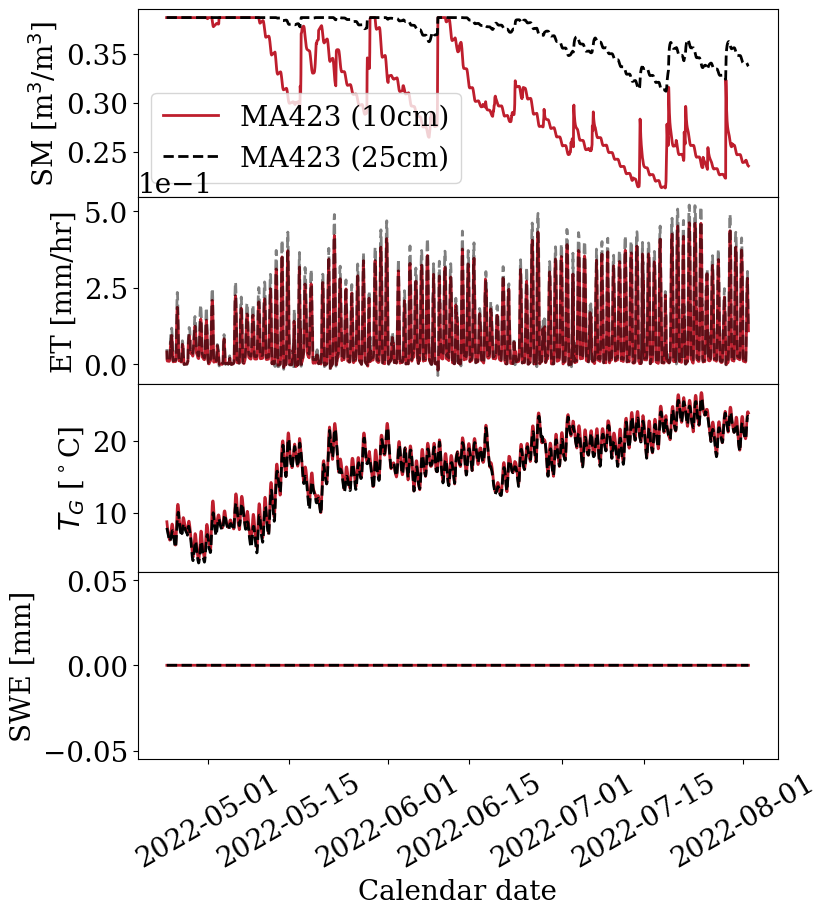

In [20]:
#Only for specific time in 2022: 24th April to 3rd October

from datetime import datetime, timedelta
d = datetime(2018, 1, 1, 0, 0)

#print(d + timedelta(hours = time_array_plot[0,2]))
time_array_one_row = np.linspace(8760*4+2735,8760*4+5135,2401)#time_array_plot[0,:]

time_array_datetime = ([d + timedelta(hours = i) for i in time_array_one_row])

#time_array_datetime = np.tile(t_time_datetime, (20,1))

#plotting components of water balance
fig, axs = plt.subplots(4, sharex=True, figsize=(8,10) , dpi=100)
#fig.suptitle('Little Washita Water Balance')
axs[0].plot(time_array_datetime,soil_moisture_point10cmavg[8760*4+2735-1:8760*4+5135,17,7], 'k-', linewidth=2,alpha=1,label='MA423 (10cm)', color = red)
axs[0].plot(time_array_datetime,soil_moisture_point25cmavg[8760*4+2735-1:8760*4+5135,17,7], 'k--', linewidth=2,alpha=1,label='MA423 (25cm)')
axs[0].legend(loc='lower left')
axs[0].set_ylabel("SM [m$^3$/m$^3$]")
axs[1].plot(time_array_datetime[1:],np.nanmean(et_plot[8760*4+2735-1:8760*4+5135-1]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[1].plot(time_array_datetime[1:],et_plot[8760*4+2735-1:8760*4+5135-1,17,7], 'k--', linewidth=2,alpha=0.5)
axs[1].set_ylabel("ET [mm/hr]")
axs[2].plot(time_array_datetime[1:],np.nanmean(grnd_plot[8760*4+2735-1:8760*4+5135-1]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[2].plot(time_array_datetime[1:],grnd_plot[8760*4+2735-1:8760*4+5135-1,17,7], 'k--', linewidth=2,alpha=1)
axs[2].set_ylabel("$T_G$ [$^\circ$C]")
axs[3].plot(time_array_datetime[1:],np.nanmean(swe_plot[8760*4+2735-1:8760*4+5135-1]*np.kron(nanmask[-1,:,:],np.ones(((len(time_array_one_row)-1,1,1)))), axis=(1,2)), linewidth=2, color = red)
axs[3].plot(time_array_datetime[1:],swe_plot[8760*4+2735-1:8760*4+5135-1,17,7], 'k--', linewidth=2,alpha=1)
axs[3].set_ylabel("SWE [mm]")
plt.xlabel('Calendar date')
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xticks(rotation = 30)
plt.savefig(f'{run_dir}/../MA_time_sim_type{sim_type}_specific_2022_soil_moisturespecific.pdf',bbox_inches='tight', dpi = 600)
plt.savefig(f'{run_dir}/../MA_time_sim_type{sim_type}_specific_2022_soil_moisturespecific.png',bbox_inches='tight', dpi = 600)
np.savez(f'{run_dir}/../MA_time{icount}hr_sim_type{sim_type}_storage_specific_2022_soil_moisturespecific',time_array_datetime,et_plot,soil_moisture_1m,grnd_plot,swe_plot,soil_moisture_point10cmavg,soil_moisture_point25cmavg)  